#GENETIC ALGORITHMS
---

##0.REFERENCE AND CONTEXT

**Introduction**

Genetic Algorithms (GAs) are among the most influential optimization techniques in artificial intelligence. Unlike gradient-based methods that rely on derivatives and smooth objective functions, Genetic Algorithms draw inspiration from biological evolution. Candidate solutions compete for survival, reproduce through crossover, undergo mutation, and gradually evolve toward increasingly optimal solutions. This evolutionary process allows Genetic Algorithms to solve complex optimization problems where traditional methods may struggle.

In finance, portfolio construction is a natural application for evolutionary optimization. Investors seek allocations that maximize expected returns while controlling risk. Traditional optimization methods, such as Mean-Variance Optimization, rely on mathematical assumptions and often suffer from instability when expected returns and covariance estimates change. Genetic Algorithms provide an alternative approach by searching directly through the space of possible portfolio allocations.

The central idea of a Genetic Algorithm is the chromosome. In this notebook, each chromosome represents a portfolio allocation across multiple assets. A population of candidate portfolios is generated, evaluated according to a fitness function, and evolved over multiple generations. The fitness function measures portfolio quality using the Sharpe Ratio, one of the most widely used risk-adjusted performance metrics in finance.

Students will learn how evolutionary systems encode candidate solutions, evaluate fitness, select parents, perform crossover, and apply mutation. These concepts are foundational not only in optimization but also in broader areas of artificial intelligence such as evolutionary strategies, neuroevolution, symbolic regression, and automated machine learning.

The dataset used in this notebook consists of historical market prices obtained through Yahoo Finance. We construct a diversified universe including equities, bonds, real estate, gold, and emerging markets. This allows students to observe how the Genetic Algorithm allocates capital among different asset classes in response to historical performance and risk characteristics.

The notebook also compares the evolutionary solution against thousands of randomly generated portfolios. This comparison provides a clear demonstration of how evolutionary search improves portfolio quality over successive generations. Visualization of the optimization process reveals how the population gradually converges toward higher fitness solutions.

By the end of this chapter, students will understand the mechanics of Genetic Algorithms, appreciate their role in optimization problems, and gain practical experience applying evolutionary computation to a realistic portfolio management challenge. This chapter serves as an important bridge between machine learning, optimization, and autonomous decision systems.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, installs required libraries, configures reproducibility, creates project folders, and verifies the execution environment.

In [1]:
# CELL 1
# Environment Setup

!pip -q install yfinance

import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path("/content/chapter12_genetic_algorithm")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)

Run ID: run_20260606_131105_utc


##2.HISTORICAL MARKET DATA

**Explanation for Cell 2**

This cell downloads historical market data for a diversified universe of ETFs.

In [4]:
# CELL 2
# Download Market Data

TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "GLD",
    "TLT",
    "EEM",
    "VNQ"
]

prices = yf.download(
    TICKERS,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna()

print(prices.tail())

Ticker            EEM         GLD         IWM         QQQ         SPY  \
Date                                                                    
2025-12-24  54.419998  411.929993  252.261276  623.144287  688.499695   
2025-12-26  54.799999  416.739990  250.973557  623.104309  688.429871   
2025-12-29  54.660000  398.600006  249.436295  620.088135  685.976562   
2025-12-30  54.880001  398.890015  247.589569  618.649902  685.138916   
2025-12-31  54.709999  396.309998  245.722900  613.536377  680.062744   

Ticker            TLT        VNQ  
Date                              
2025-12-24  86.395973  87.821198  
2025-12-26  86.111366  87.920135  
2025-12-29  86.435234  88.098236  
2025-12-30  86.229134  88.276329  
2025-12-31  85.542137  87.554047  


##3.MAIN ASSET FEATURES

**Explanation for Cell 3**

This cell computes returns and explores basic asset characteristics.

          Return  Volatility
Ticker                      
EEM     0.061325    0.209247
GLD     0.156023    0.151352
IWM     0.101969    0.246024
QQQ     0.205444    0.240512
SPY     0.151407    0.194595
TLT    -0.005556    0.157503
VNQ     0.072028    0.222308


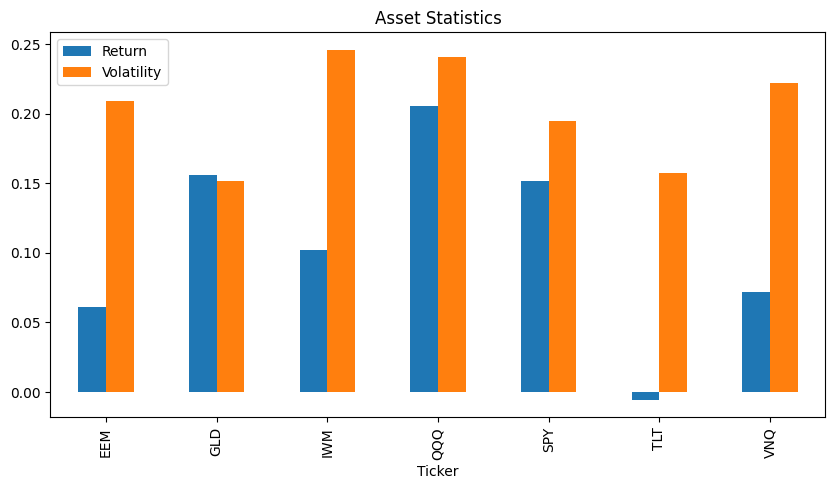

In [5]:
# CELL 3
# Return Analysis

returns = prices.pct_change().dropna()

annual_returns = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)

summary = pd.DataFrame(
    {
        "Return": annual_returns,
        "Volatility": annual_volatility
    }
)

print(summary)

summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Asset Statistics")
plt.show()

##4.THE CHROMOSOME REPRESENTATION

**Explanation for Cell 4**

This cell defines the chromosome representation used by the Genetic Algorithm.

In [6]:
# CELL 4
# Chromosome Representation

N_ASSETS = len(TICKERS)

def create_chromosome():

    weights = np.random.random(
        N_ASSETS
    )

    weights = (
        weights /
        weights.sum()
    )

    return weights

sample_chromosome = create_chromosome()

print(sample_chromosome)
print(sample_chromosome.sum())

[0.12377385 0.31418148 0.24190121 0.19783799 0.0515593  0.05155133
 0.01919483]
0.9999999999999999


##5.THE FITNESS FUNCTION

**Explanation for Cell 5**

This cell defines the fitness function based on the Sharpe Ratio.

In [7]:
# CELL 5
# Fitness Function

RISK_FREE_RATE = 0.02

cov_matrix = (
    returns.cov() * 252
)

def fitness(weights):

    portfolio_return = np.sum(
        annual_returns * weights
    )

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

    sharpe = (
        portfolio_return
        -
        RISK_FREE_RATE
    ) / portfolio_volatility

    return sharpe

##6.INITIAL POPULATION AND EVOLUTIONARY OPERATORS

**Explanation for Cell 6**

This cell creates the initial population and evolutionary operators.

In [8]:
# CELL 6
# Population Initialization

POPULATION_SIZE = 100

population = [
    create_chromosome()
    for _ in range(
        POPULATION_SIZE
    )
]

def crossover(
    parent1,
    parent2
):

    alpha = np.random.random()

    child = (
        alpha * parent1
        +
        (1 - alpha) * parent2
    )

    child /= child.sum()

    return child

def mutate(
    chromosome,
    mutation_rate=0.05
):

    if random.random() < mutation_rate:

        idx = random.randint(
            0,
            len(chromosome)-1
        )

        chromosome[idx] += np.random.normal(
            0,
            0.05
        )

        chromosome = np.maximum(
            chromosome,
            0
        )

        chromosome /= chromosome.sum()

    return chromosome

##7.THE EVOLUTIONARY OPTIMIZATION PROCESS

**Explanation for Cell 7**

This cell executes the evolutionary optimization process.

In [9]:
# CELL 7
# Evolution Engine

GENERATIONS = 200

best_fitness_history = []

for generation in range(
    GENERATIONS
):

    scores = np.array(
        [
            fitness(chromosome)
            for chromosome in population
        ]
    )

    ranked_indices = np.argsort(
        scores
    )[::-1]

    population = [
        population[i]
        for i in ranked_indices
    ]

    best_fitness_history.append(
        scores.max()
    )

    elite_count = int(
        POPULATION_SIZE * 0.10
    )

    new_population = (
        population[:elite_count]
    )

    while len(
        new_population
    ) < POPULATION_SIZE:

        parent1 = random.choice(
            population[:20]
        )

        parent2 = random.choice(
            population[:20]
        )

        child = crossover(
            parent1,
            parent2
        )

        child = mutate(child)

        new_population.append(
            child
        )

    population = new_population

    if generation % 20 == 0:

        print(
            f"Generation {generation} "
            f"Best Sharpe {best_fitness_history[-1]:.3f}"
        )

Generation 0 Best Sharpe 0.887
Generation 20 Best Sharpe 1.054
Generation 40 Best Sharpe 1.105
Generation 60 Best Sharpe 1.116
Generation 80 Best Sharpe 1.122
Generation 100 Best Sharpe 1.126
Generation 120 Best Sharpe 1.128
Generation 140 Best Sharpe 1.128
Generation 160 Best Sharpe 1.128
Generation 180 Best Sharpe 1.128


##8.THE OPTIMAL PORTFOLIO

**Explanation for Cell 8**

This cell identifies the optimal portfolio found by the Genetic Algorithm.

In [10]:
# CELL 8
# Optimization Results

scores = np.array(
    [
        fitness(chromosome)
        for chromosome in population
    ]
)

best_index = np.argmax(scores)

best_portfolio = population[
    best_index
]

best_sharpe = scores[
    best_index
]

allocation = pd.Series(
    best_portfolio,
    index=TICKERS
)

print(
    "Best Sharpe Ratio:",
    round(best_sharpe, 4)
)

print(
    allocation.sort_values(
        ascending=False
    )
)

Best Sharpe Ratio: 1.1281
QQQ    6.575950e-01
GLD    3.424050e-01
TLT    8.443672e-16
EEM    3.147468e-16
VNQ    9.555079e-17
SPY    4.008465e-17
IWM    0.000000e+00
dtype: float64


##9.COMPARISON VS.RANDOM PORTFOLIOS

**Explanation for Cell 9**

This cell compares the Genetic Algorithm solution against randomly generated portfolios.

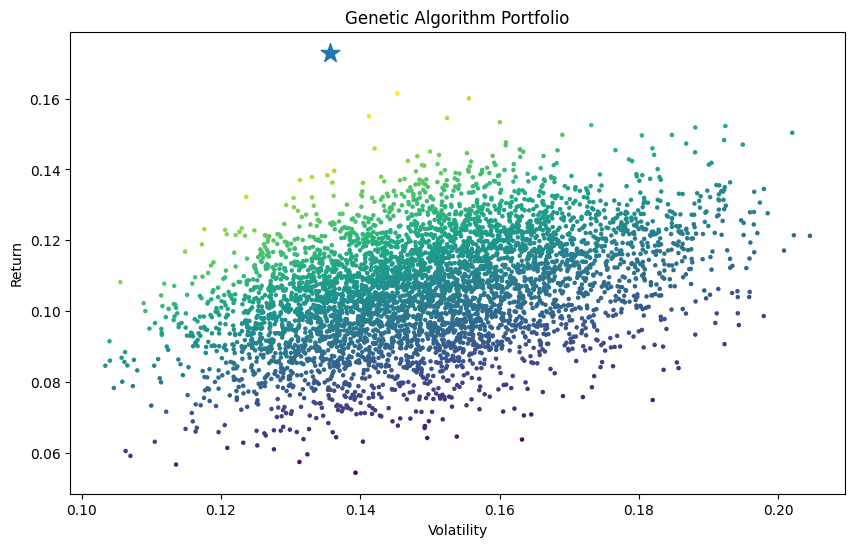

In [11]:
# CELL 9
# Efficient Frontier Comparison

random_returns = []
random_vols = []
random_sharpes = []

for _ in range(5000):

    weights = create_chromosome()

    ret = np.sum(
        annual_returns * weights
    )

    vol = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

    sharpe = (
        ret -
        RISK_FREE_RATE
    ) / vol

    random_returns.append(ret)
    random_vols.append(vol)
    random_sharpes.append(sharpe)

plt.figure(figsize=(10,6))

plt.scatter(
    random_vols,
    random_returns,
    c=random_sharpes,
    s=5
)

best_return = np.sum(
    annual_returns *
    best_portfolio
)

best_vol = np.sqrt(
    np.dot(
        best_portfolio.T,
        np.dot(
            cov_matrix,
            best_portfolio
        )
    )
)

plt.scatter(
    best_vol,
    best_return,
    s=200,
    marker="*"
)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title(
    "Genetic Algorithm Portfolio"
)

plt.show()

##10.FINAL ALLOCATION

**Explanation for Cell 10**

This cell visualizes the optimization process and final allocation.

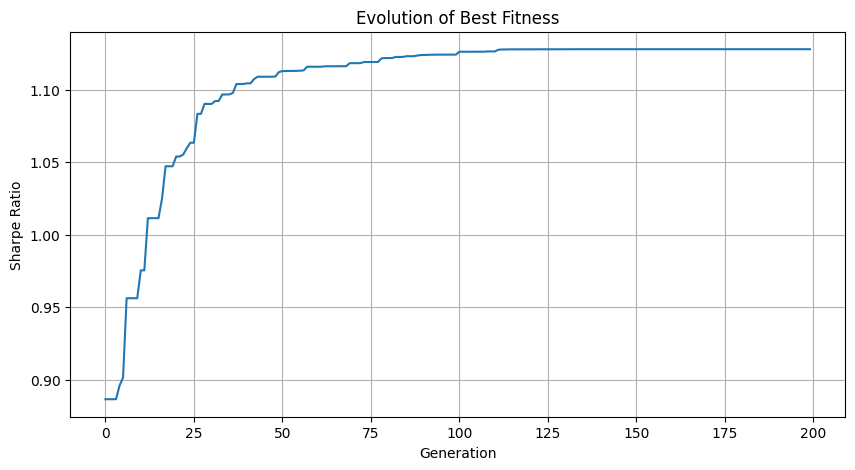

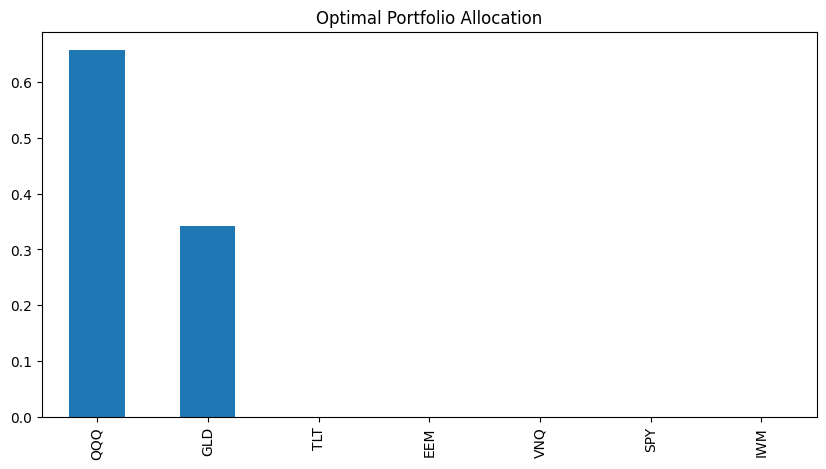

In [12]:
# CELL 10
# Portfolio Allocation Analysis

plt.figure(figsize=(10,5))

plt.plot(
    best_fitness_history
)

plt.title(
    "Evolution of Best Fitness"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Sharpe Ratio"
)

plt.grid(True)

plt.show()

allocation.sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Optimal Portfolio Allocation"
)

plt.show()

##11.SUMMARY AND EXPLANATION

In [13]:
# CELL 11
# GPT-5.2 Analysis

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

summary = {
    "best_sharpe": float(best_sharpe),
    "allocation": allocation.to_dict(),
    "assets": TICKERS,
    "generations": GENERATIONS,
    "population_size": POPULATION_SIZE
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Analyze this genetic algorithm
portfolio optimization experiment.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""
)

print(
    response.output_text
)

{
  "summary": {
    "experiment_type": "genetic_algorithm_portfolio_optimization",
    "objective": "maximize_sharpe_ratio",
    "best_sharpe": 1.1280571712306247,
    "generations": 200,
    "population_size": 100,
    "asset_universe": [
      "SPY",
      "QQQ",
      "IWM",
      "GLD",
      "TLT",
      "EEM",
      "VNQ"
    ],
    "num_assets": 7,
    "effective_num_assets_nonzero": 2,
    "result_characterization": "highly_concentrated_two_asset_solution"
  },
  "allocation_analysis": {
    "raw_allocation": {
      "SPY": 4.008464606776842e-17,
      "QQQ": 0.6575949695303624,
      "IWM": 0.0,
      "GLD": 0.3424050304696362,
      "TLT": 8.443671865201926e-16,
      "EEM": 3.147467607739111e-16,
      "VNQ": 9.555078758488826e-17
    },
    "weights_sum": 0.9999999999999999,
    "sum_close_to_one": true,
    "nonnegativity_satisfied": true,
    "near_zero_threshold": 1e-6,
    "cleaned_allocation": {
      "QQQ": 0.6575949695303624,
      "GLD": 0.3424050304696362,
      "

##12.CONCLUSIONS

**Conclusion**

This chapter introduced Genetic Algorithms as a powerful evolutionary optimization technique. Unlike gradient-based learning systems, Genetic Algorithms search for solutions through a process inspired by biological evolution. Candidate solutions compete, reproduce, mutate, and gradually improve over successive generations.

The portfolio optimization problem provided a natural environment for demonstrating evolutionary computation. Each chromosome represented a portfolio allocation, while the fitness function measured portfolio quality using the Sharpe Ratio. Through repeated selection, crossover, and mutation, the population evolved toward increasingly attractive risk-adjusted investment strategies.

Students observed how a Genetic Algorithm can efficiently search a large solution space without requiring derivatives, convexity assumptions, or explicit mathematical structure. This flexibility is one of the major strengths of evolutionary optimization. Many real-world optimization problems involve discontinuities, nonlinearities, constraints, or multiple local optima that make traditional optimization methods difficult to apply. Genetic Algorithms often provide robust alternatives in such situations.

The comparison between randomly generated portfolios and the evolved solution highlighted the value of evolutionary search. While random sampling occasionally discovers attractive portfolios, the Genetic Algorithm systematically improves solutions over time. The fitness evolution chart clearly demonstrated this process as the population converged toward increasingly effective allocations.

Beyond finance, Genetic Algorithms have broad applications across artificial intelligence. They are used in engineering design, scheduling, logistics, robotics, feature selection, hyperparameter optimization, symbolic regression, and automated machine learning. Evolutionary methods are particularly useful when objective functions are complex, noisy, or difficult to differentiate.

This chapter also introduced students to several important concepts that appear throughout optimization and AI research. Chromosomes, populations, fitness functions, crossover operators, mutation operators, and evolutionary selection form a common vocabulary used across many evolutionary computation techniques.

Most importantly, Genetic Algorithms provide a fundamentally different perspective on learning and optimization. Rather than adjusting parameters through gradients, they explore the solution space through variation and selection. This perspective complements the neural networks, reinforcement learning systems, and graph models studied in earlier chapters.

The next chapter will move into Quantum Machine Learning, where concepts from quantum computing are combined with machine learning techniques. Students will explore how quantum-inspired algorithms and quantum representations may provide new approaches to optimization, classification, and representation learning.